In [1]:
#-- Import library. --#
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#-- Import data. --#
student_data = pd.read_csv('student_grade.csv')

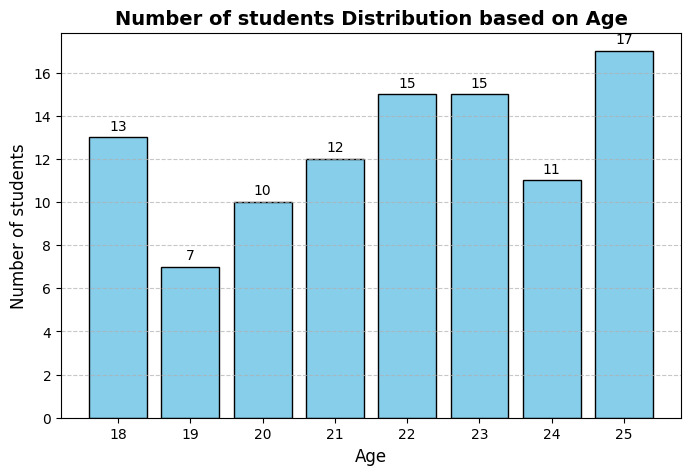

In [2]:
#-- Number of students based on Age. --#
#-- Count number in each age and sorted according to accending. --#
age_counts = student_data["age"].value_counts().sort_index()
#- Generate Figure and Axes. -#
fig, ax = plt.subplots(figsize=(8, 5))
#-- Create bar graph. --#
bars = ax.bar(
    age_counts.index, age_counts.values, color="skyblue", edgecolor="black"
)
#-- Add data above on each bar. --#
ax.bar_label(bars, padding=3)
#-- Set labels and names. --#
ax.set_title("Number of students Distribution based on Age", fontsize=14, fontweight="bold")
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Number of students", fontsize=12)
#-- Add shadow line. --#
ax.grid(axis="y", linestyle="--", alpha=0.7)
#-- Show the graph. --#
plt.show()
fig.savefig("Age_Distribution.png", dpi=300, bbox_inches="tight")


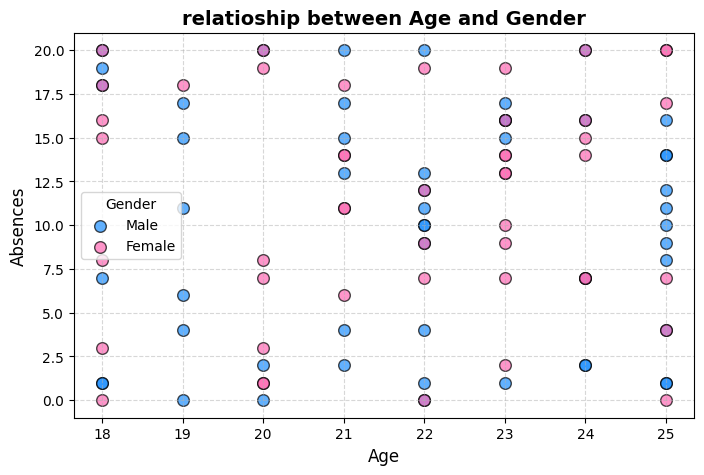

In [3]:
#-- Scatter Plot of Gender. --#
#-- Categorize Gender. --#
male_data = student_data[student_data["gender"] == "Male"]
female_data = student_data[student_data["gender"] == "Female"]
#-- Create drawing frame. --#
fig, ax = plt.subplots(figsize=(8,5))
#-- Drawing Male and Female Group. --#
ax.scatter(male_data["age"], male_data["absences"], color="dodgerblue", label="Male",
           s=70, edgecolors="black", alpha=0.7)
ax.scatter(female_data["age"], female_data["absences"], color="hotpink", label="Female",
           s=70, edgecolors="black", alpha=0.7)
#-- Setting information for the scatter plot. --#
ax.set_title("relatioship between Age and Gender", fontsize=14, fontweight="bold")
ax.set_xlabel("Age", fontsize=12)
ax.set_ylabel("Absences", fontsize=12)
#-- Explaination. --#
ax.legend(title="Gender")
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()
fig.savefig("Distirbution_Age_and_Gender.png", dpi=300, bbox_inches="tight")


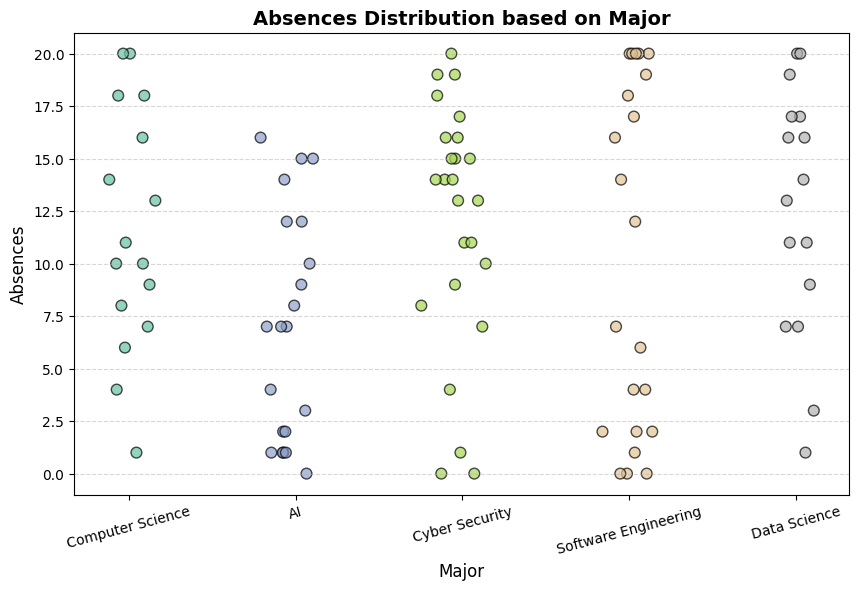

In [4]:
#-- Plot Graph of Major Distribution. --#
import numpy as np
#-- Change Name of Major into numbers for caclulating. --#
unique_majors = student_data["major"].unique()
major_mapping = {major: i for i, major in enumerate(unique_majors)}
student_data["major_num"] = student_data["major"].map(major_mapping)
#-- Generate frame of the graph. --#
fig, ax = plt.subplots(figsize=(10, 6))
jitter = np.random.normal(0, 0.08, size=len(student_data)) #-- Add nature correlation. --#
#-- Draw the inside of the graph. --#
scatter = ax.scatter(student_data["major_num"] + jitter, student_data["absences"], alpha=0.7,
                     c=student_data["major_num"], cmap="Set2", edgecolors="black", s=60)
#-- Label for x. --#
ax.set_xticks(range(len(unique_majors)))
ax.set_xticklabels(unique_majors, rotation=15)
#-- Title Setting. --#
ax.set_title("Absences Distribution based on Major", fontsize=14, fontweight="bold")
ax.set_xlabel("Major", fontsize=12)
ax.set_ylabel("Absences", fontsize=12)
ax.grid(axis="y", linestyle="--", alpha=0.5)
#-- Show the graph. --#
plt.show()
fig.savefig("Absences_Distribution_based_on_Major.png", dpi=300, bbox_inches="tight")

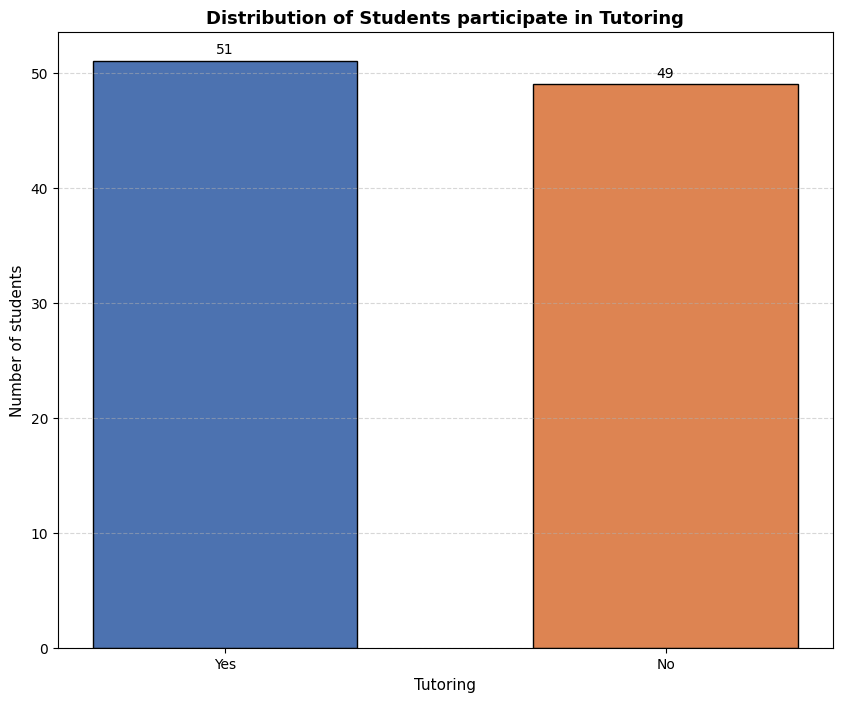

In [5]:
#-- Histogram Graph for the Tutoring. --#
tutoring_counts = student_data['tutoring'].value_counts()
#-- Draw Yes and No column. --#
fig, ax = plt.subplots(figsize=(10,8))
bars = ax.bar(tutoring_counts.index, tutoring_counts.values, color=["#4C72B0", "#DD8452"],
              edgecolor="black", width=0.6)
#-- Take labe on top of column. --#
ax.bar_label(bars, padding=3)
# Tùy chỉnh thông tin trục và tiêu đề
ax.set_title("Distribution of Students participate in Tutoring", fontsize=13, fontweight="bold")
ax.set_xlabel("Tutoring", fontsize=11)
ax.set_ylabel("Number of students", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)
#-- Shows the graph. --#
plt.show()
fig.savefig("Distirbution_of_Students_Participate_in_Tutoring.png", dpi=300, bbox_inches="tight")

C:\Users\DELL\AppData\Local\Temp\ipykernel_1196\3059587848.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


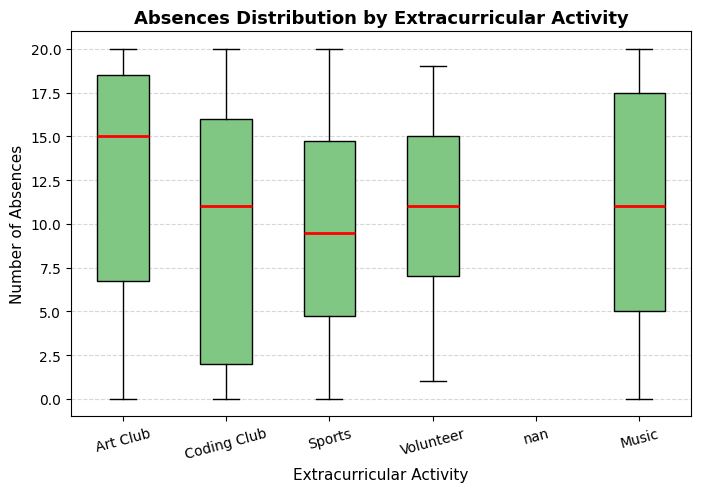

In [6]:
#-- Graph for Curriculum Activities. --#
unique_activities = student_data["curriculum_activities"].unique()
grouped_data = []
for activity in unique_activities:
    absences_by_activity = student_data[student_data["curriculum_activities"] == activity]["absences"]
    grouped_data.append(absences_by_activity)
# Initialize an independent figure and axis
fig, ax = plt.subplots(figsize=(8, 5))
# Render the Boxplot
box = ax.boxplot(
    grouped_data,
    patch_artist=True,  # Enables color filling for boxes
    labels=unique_activities,  # Assign labels to the X-axis
    medianprops=dict(
        color="red", linewidth=2
    ),  # Highlight the median line in red
)
# Style the boxes with a soft green background fill
for patch in box["boxes"]:
    patch.set_facecolor("#81C784")
# Customize titles and axis labels
ax.set_title(
    "Absences Distribution by Extracurricular Activity",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Extracurricular Activity", fontsize=11)
ax.set_ylabel("Number of Absences", fontsize=11)
# Rotate X-axis labels slightly to prevent text overlapping
ax.set_xticklabels(unique_activities, rotation=15)
ax.grid(axis="y", linestyle="--", alpha=0.5)
# Render the plot
plt.show()
fig.savefig("Absences_Distribution_by_Curriculum_Activities.png", dpi=300, bbox_inches="tight")